***
# <span style="font-family: 'Ubuntu'; font-weight: 200; font-size: 36px; color: indianred;">[1] Introdução</span>

***

### [1.1] Bibliotecas

In [17]:
from plots import print_caminho, caminho_para_grafo, plot_metricas

### [1.2] Dados do Problema

In [18]:
from modelagem import Estado
from modelagem import TEMPOS, PESSOAS

print(f"Dicionário de tempos: {TEMPOS}, Conjunto de pessoas: {PESSOAS}")

estado_inicial = Estado(grupo_inicio=PESSOAS, tocha_inicio=True)
estado_final = Estado(grupo_inicio=set(), tocha_inicio=False)
print(f"Estado inicial: {estado_inicial}")
print(f"Estado final: {estado_final}")

Dicionário de tempos: {'A': 1, 'B': 2, 'C': 5, 'D': 10}, Conjunto de pessoas: {'D', 'A', 'C', 'B'}
Estado inicial: {A, B, C, D} inicio
Estado final: {} final


***
# <span style="font-family: 'Ubuntu'; font-weight: 200; font-size: 36px; color: gray;">[2] Conhecendo a Modelagem</span>

***

### [2.1] Geração do Grupo Viajante

In [19]:
from modelagem import gerar_grupos_viajantes

print("possíveis grupos viajantes para o estado inicial: ")
for grupo_viajante in gerar_grupos_viajantes(PESSOAS):
    print(grupo_viajante, end=' ')

possíveis grupos viajantes para o estado inicial: 
{'D'} {'A'} {'C'} {'B'} {'D', 'A'} {'D', 'C'} {'D', 'B'} {'A', 'C'} {'A', 'B'} {'C', 'B'} 

### [2.2] Função Sucessora

In [20]:
from modelagem import funcao_sucessora

print("Sucessores do estado inicial:")
for passo in funcao_sucessora(estado_inicial):
    print(passo)

Sucessores do estado inicial:
Estado destino: {A, B, C} final; Passageiros: {D}; Custo: 10
Estado destino: {B, C, D} final; Passageiros: {A}; Custo: 1
Estado destino: {A, B, D} final; Passageiros: {C}; Custo: 5
Estado destino: {A, C, D} final; Passageiros: {B}; Custo: 2
Estado destino: {B, C} final; Passageiros: {A, D}; Custo: 10
Estado destino: {A, B} final; Passageiros: {C, D}; Custo: 10
Estado destino: {A, C} final; Passageiros: {B, D}; Custo: 10
Estado destino: {B, D} final; Passageiros: {A, C}; Custo: 5
Estado destino: {C, D} final; Passageiros: {A, B}; Custo: 2
Estado destino: {A, D} final; Passageiros: {B, C}; Custo: 5


***
# <span style="font-family: 'Ubuntu'; font-weight: 200; font-size: 36px; color: royalblue;">[3] Execução dos Algoritmos</span>

***

In [21]:
resultados_algoritmos = {}

### [3.1] Métodos de busca não informada

#### Busca em largura (BFS)

0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'D', 'A'} levam a tocha para o final (custo: 10)
2: Passo: {'D'} levam a tocha para o inicio (custo: 10)
3: Passo: {'D', 'C'} levam a tocha para o final (custo: 10)
4: Passo: {'D'} levam a tocha para o inicio (custo: 10)
5: Passo: {'D', 'B'} levam a tocha para o final (custo: 10)
Estado final: {} final
Custo total: 50, Tempo: 0.000301s, Nós expandidos: 20


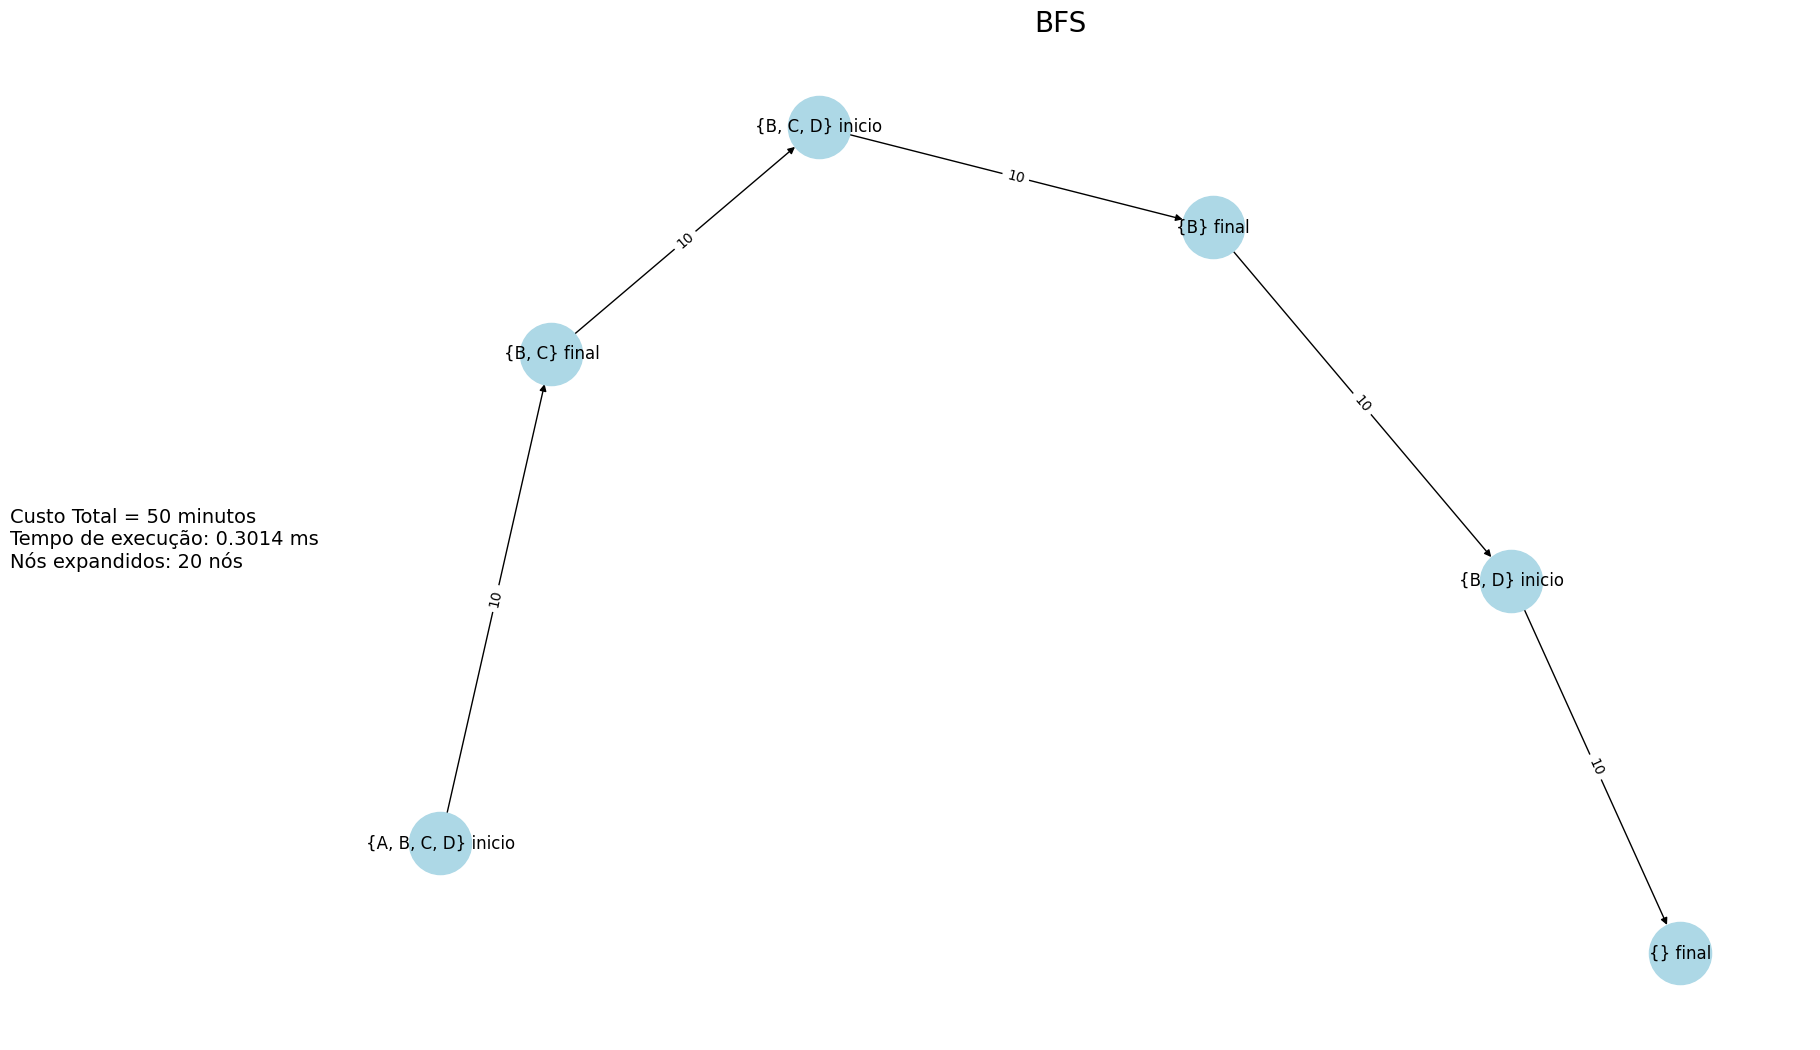

In [22]:
from algoritmos import bfs

resultados_algoritmos["BFS"] = bfs(estado_inicial, estado_final)
caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["BFS"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial, caminho, "BFS", descricao)

#### Busca em profundidade (DFS)

0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'C', 'B'} levam a tocha para o final (custo: 5)
2: Passo: {'B'} levam a tocha para o inicio (custo: 2)
3: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
4: Passo: {'C', 'B'} levam a tocha para o inicio (custo: 5)
5: Passo: {'D', 'B'} levam a tocha para o final (custo: 10)
6: Passo: {'A', 'B'} levam a tocha para o inicio (custo: 2)
7: Passo: {'C', 'B'} levam a tocha para o final (custo: 5)
8: Passo: {'B'} levam a tocha para o inicio (custo: 2)
9: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
Estado final: {} final
Custo total: 35, Tempo: 0.000209s, Nós expandidos: 13


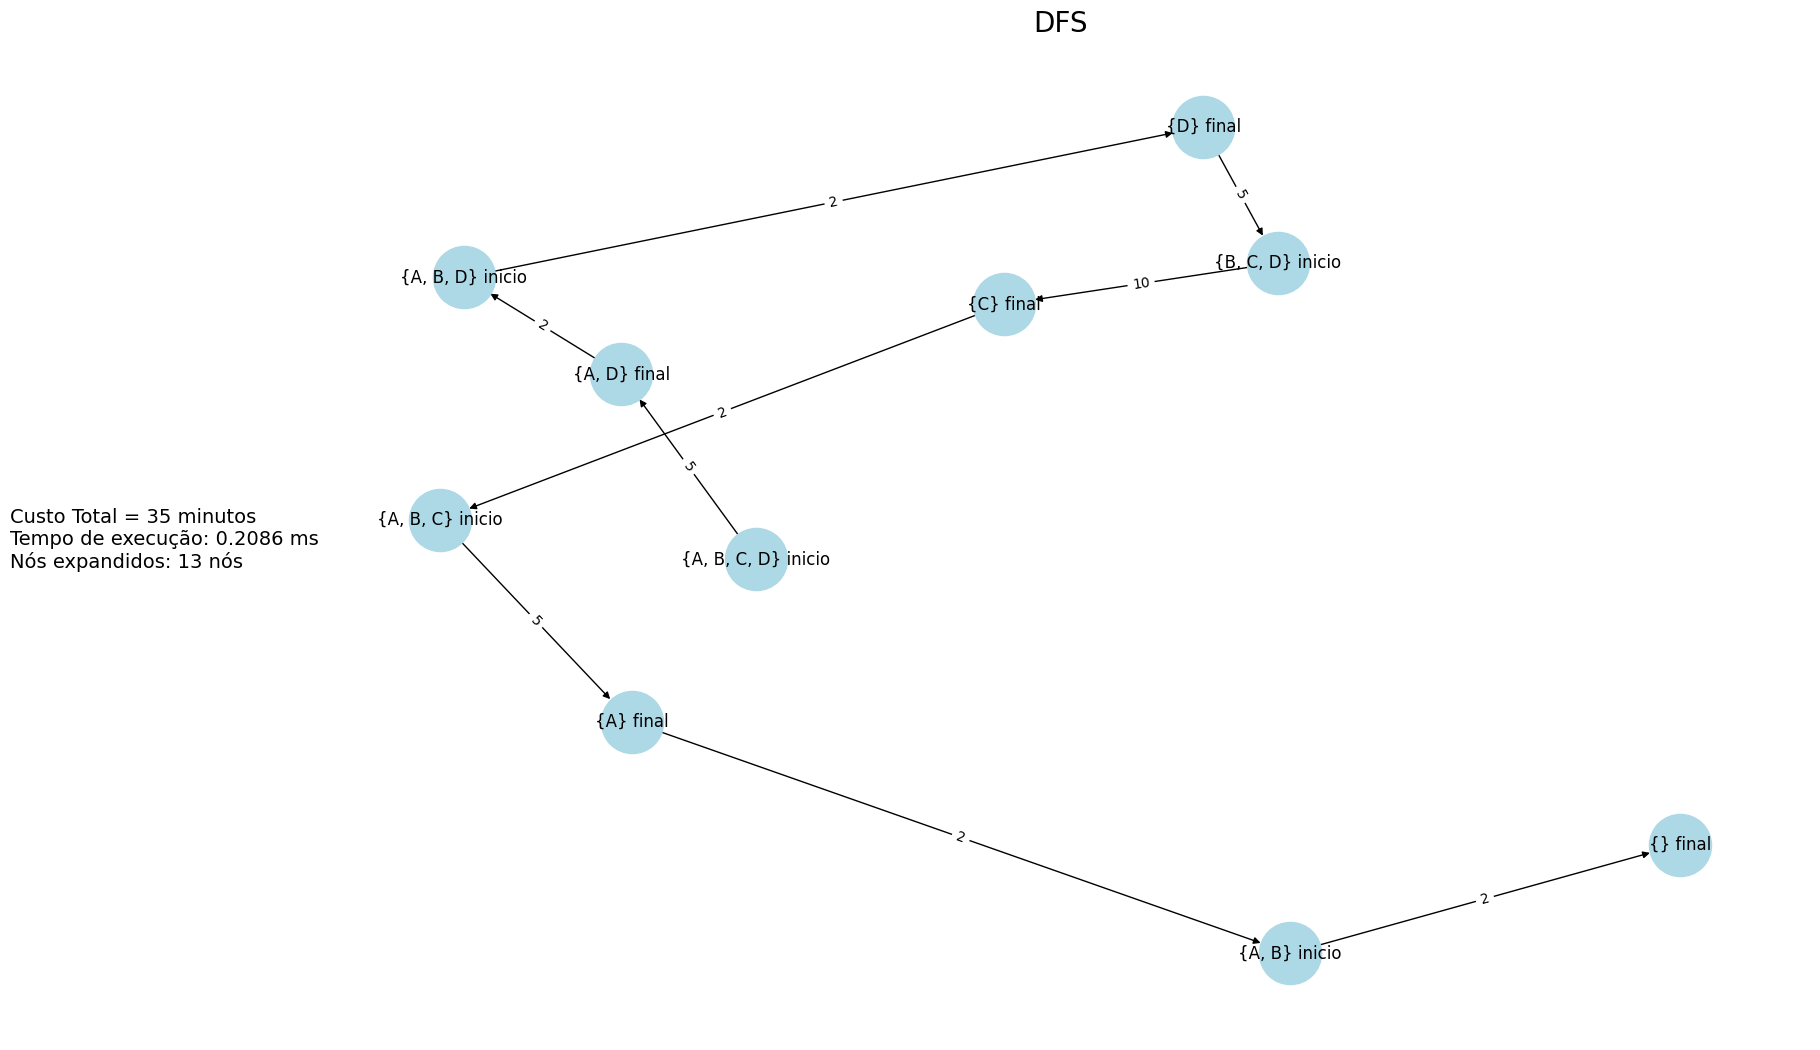

In [23]:
from algoritmos import dfs

resultados_algoritmos["DFS"] = dfs(estado_inicial, estado_final)
caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["DFS"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial, caminho, "DFS", descricao)

### [3.2] Métodos de busca informada

#### Custo Uniforme

0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
2: Passo: {'A'} levam a tocha para o inicio (custo: 1)
3: Passo: {'A', 'C'} levam a tocha para o final (custo: 5)
4: Passo: {'A'} levam a tocha para o inicio (custo: 1)
5: Passo: {'D', 'A'} levam a tocha para o final (custo: 10)
Estado final: {} final
Custo total: 19, Tempo: 0.000534s, Nós expandidos: 12


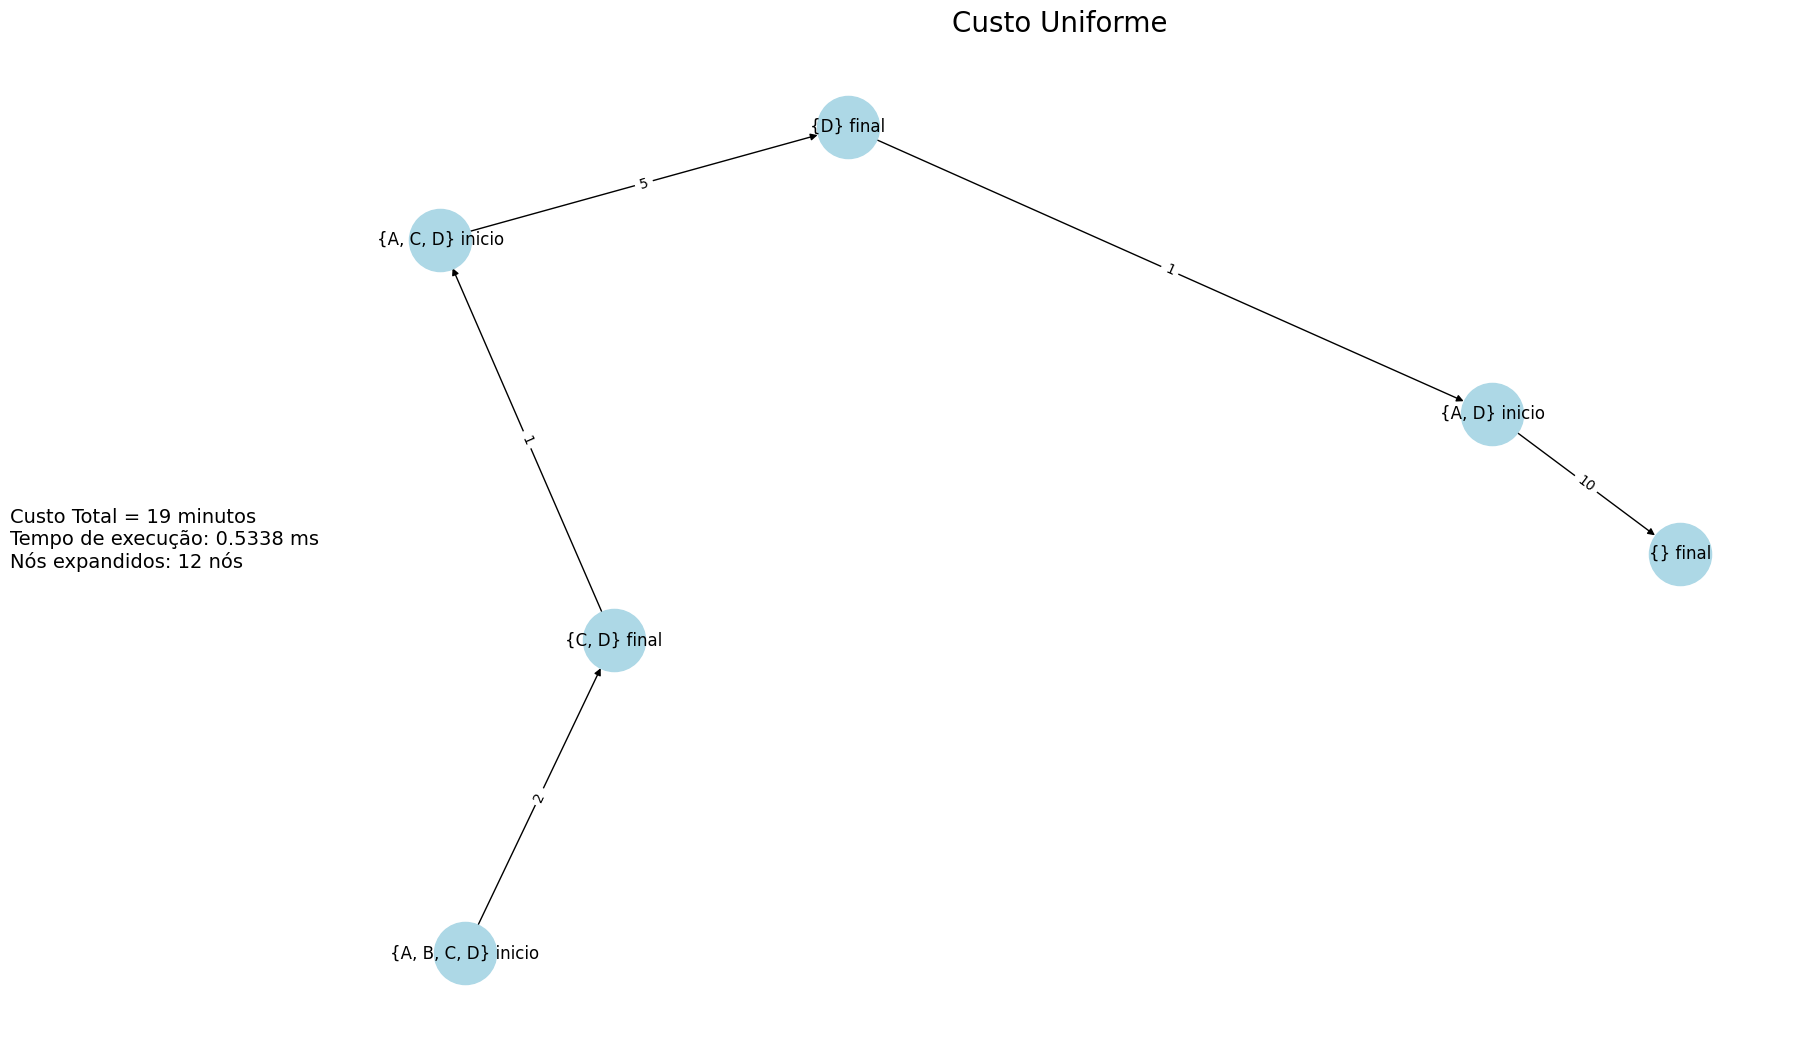

In [24]:
from algoritmos import custo_uniforme

resultados_algoritmos["Custo Uniforme"] = custo_uniforme(estado_inicial, estado_final)
caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["Custo Uniforme"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial,caminho,"Custo Uniforme",descricao)

#### A-estrela

0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
2: Passo: {'A'} levam a tocha para o inicio (custo: 1)
3: Passo: {'D', 'C'} levam a tocha para o final (custo: 10)
4: Passo: {'B'} levam a tocha para o inicio (custo: 2)
5: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
Estado final: {} final
Custo total: 17, Tempo: 0.000312s, Nós expandidos: 16


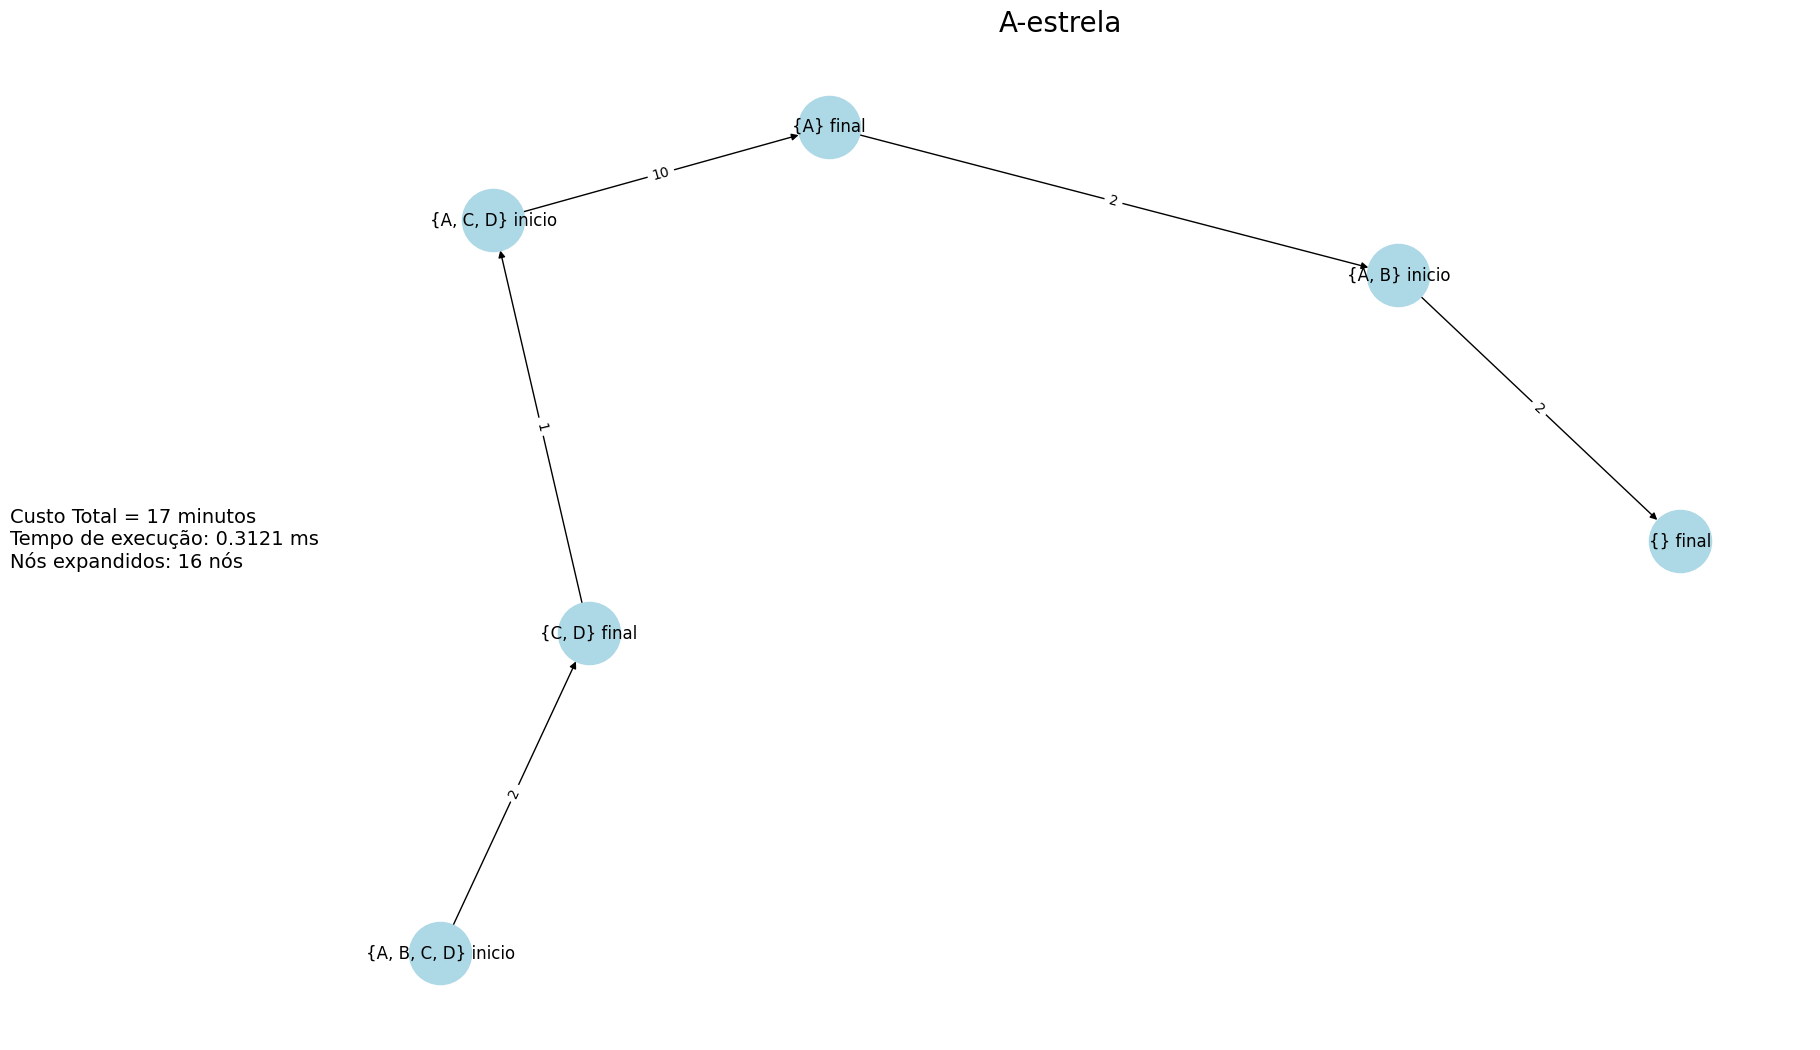

In [25]:
from algoritmos import a_estrela
from heuristicas import heuristica_maior_tempo_restante

resultados_algoritmos["A-estrela"] = a_estrela(estado_inicial, estado_final, heuristica_maior_tempo_restante)
caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["A-estrela"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial, caminho, "A-estrela", descricao)

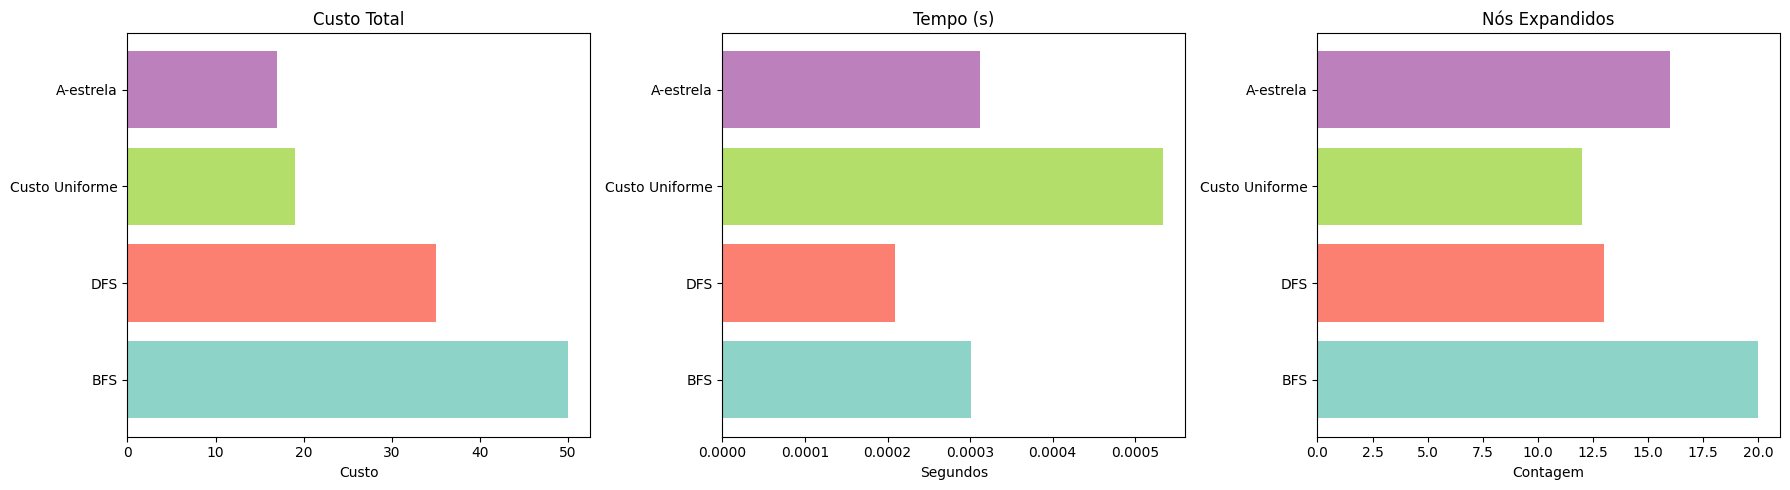

In [26]:
plot_metricas(resultados_algoritmos,"Set3")

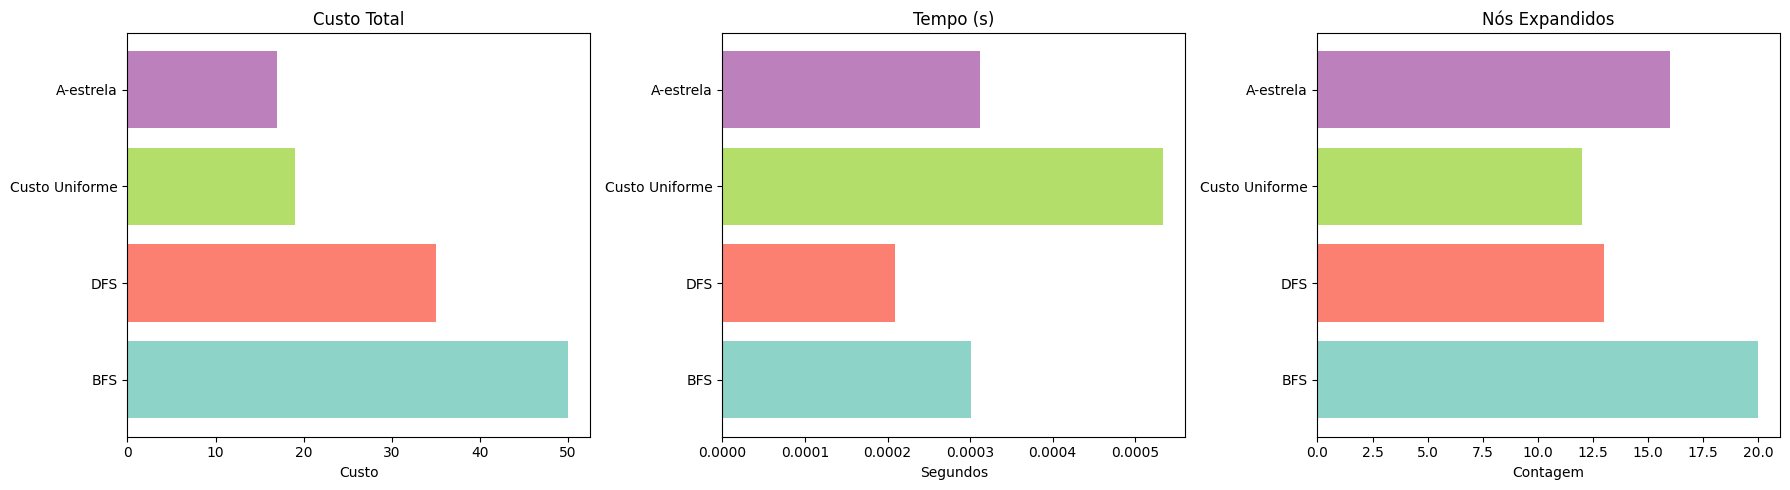

In [27]:
plot_metricas(resultados_algoritmos,"Set3")

***
# <span style="font-family: 'Ubuntu'; font-weight: 200; font-size: 36px; color: orange;">[4] Outras visualizações</span>

***

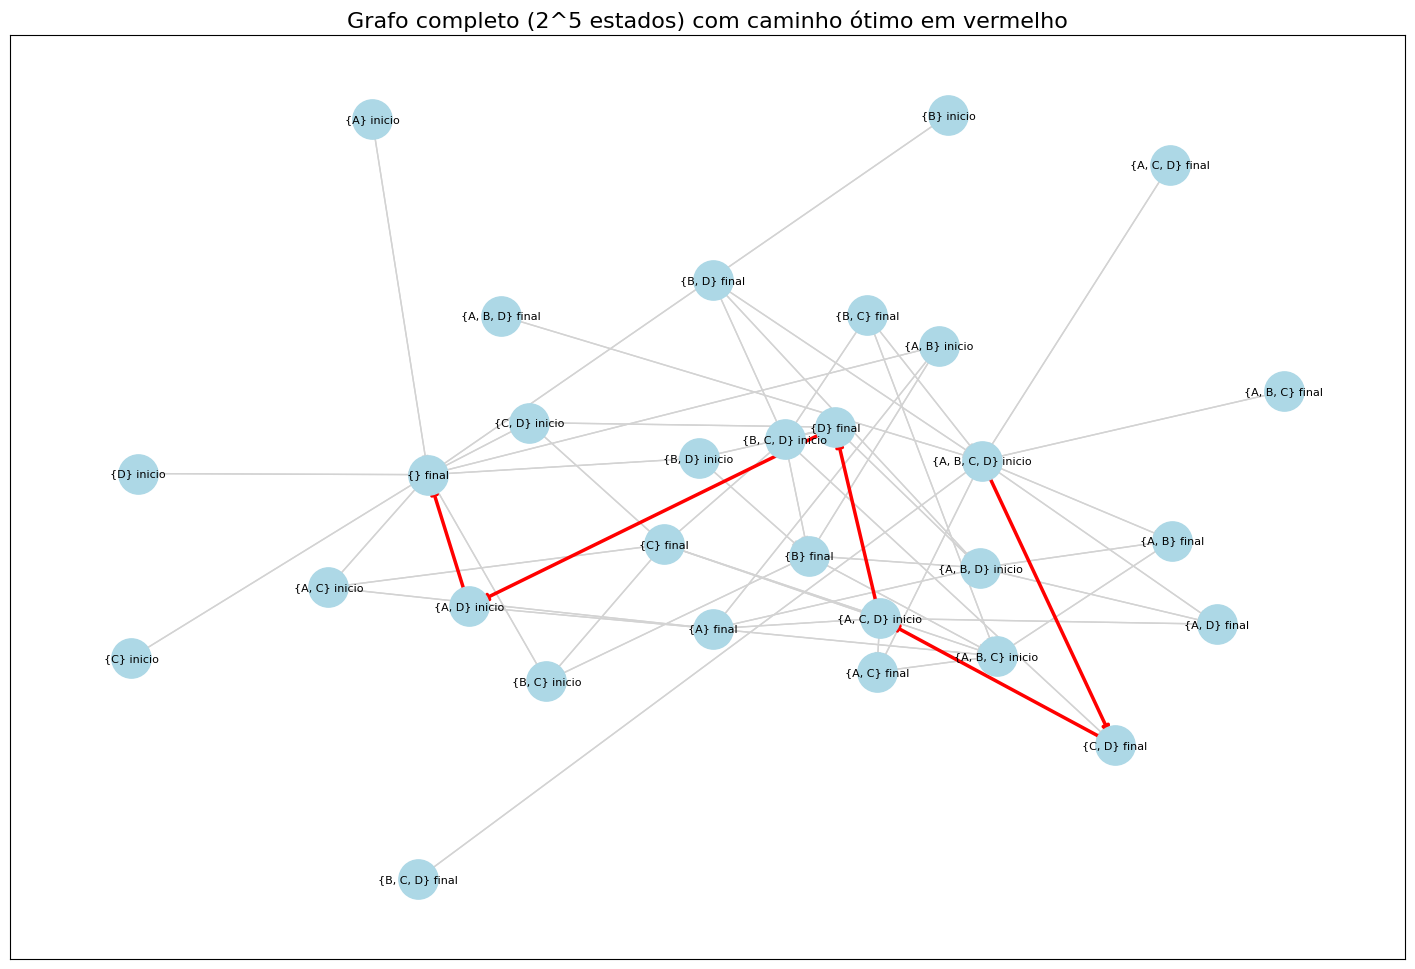

In [28]:
from plots import construir_grafo_completo, plotar_grafo_completo_com_caminho

G_completo = construir_grafo_completo()
caminho_otimo = resultados_algoritmos["Custo Uniforme"][0]  # ou "A-estrela"
plotar_grafo_completo_com_caminho(G_completo, caminho_otimo)